# 🤖 AI Face Detector - Model Demo

This notebook demonstrates how to use the **AI Face Detector** model.

## Model Information
- **Architecture**: MobileNetV2 (Transfer Learning)
- **Accuracy**: 94.5%
- **Model Size**: 8.8MB

## 📦 Model Link
https://www.kaggle.com/models/furkankoykiran/ai-face-detector-mobilenetv2

In [1]:
!pip install torch torchvision pillow -q

In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 🔍 Find Model Path

In [3]:
# Search for model file
model_base_path = '/kaggle/input'
model_path = None

for root, dirs, files in os.walk(model_base_path):
    if 'model.pth' in files:
        model_path = os.path.join(root, 'model.pth')
        break

if model_path:
    print(f"✅ Found model at: {model_path}")
else:
    print("❌ ERROR: model.pth not found!")
    print("Please add the model: ai-face-detector-mobilenetv2")

✅ Found model at: /kaggle/input/models/furkankoykiran/ai-face-detector-mobilenetv2/pytorch/pytorch/1/model.pth


## 📥 Load the Model

**Note**: The model was saved with DataParallel, so we need to remove 'module.' prefix from keys.

In [4]:
if model_path and os.path.exists(model_path):
    # Load MobileNetV2 architecture
    model = models.mobilenet_v2(weights=None)
    
    # Modify the classifier for binary classification
    model.classifier[1] = nn.Linear(model.last_channel, 1)
    
    # Load the state dict
    state_dict = torch.load(model_path, map_location=device)
    
    # Remove 'module.' prefix (model was saved with DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith('module.'):
            new_state_dict[k[7:]] = v  # Remove 'module.' prefix
        else:
            new_state_dict[k] = v
    
    # Load the modified state dict
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    
    print("✅ Model loaded successfully!")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
else:
    print("❌ Cannot load model - file not found")

✅ Model loaded successfully!
Model parameters: 2,225,153


In [5]:
# Preprocessing
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.sigmoid(output).item()
    
    result = 'AI_GENERATED' if prob > 0.5 else 'REAL'
    confidence = prob if prob > 0.5 else (1 - prob)
    
    return result, confidence, image

print("✅ Ready for inference!")

✅ Ready for inference!


## 🧪 Test with Sample Image

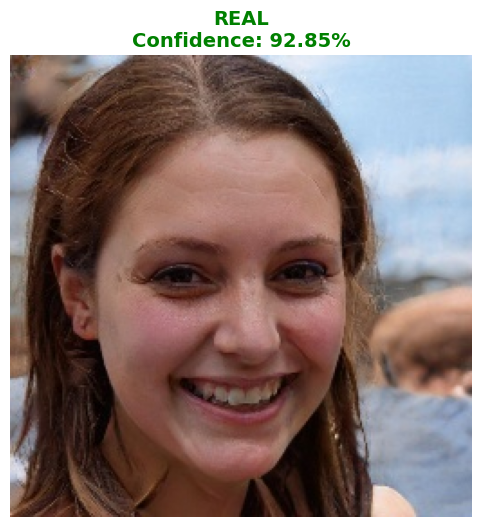


🔍 Result: REAL
📊 Confidence: 92.85%


In [6]:
# Find test images
test_image = None
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith(('.jpg', '.png')) and 'model' not in root.lower():
            test_image = os.path.join(root, file)
            break
    if test_image:
        break

if test_image:
    result, confidence, image = predict_image(test_image)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    color = 'red' if result == 'AI_GENERATED' else 'green'
    plt.title(f'{result}\nConfidence: {confidence:.2%}', fontsize=14, color=color, fontweight='bold')
    plt.show()
    
    print(f"\n🔍 Result: {result}")
    print(f"📊 Confidence: {confidence:.2%}")
else:
    print("❌ No test images found.")
    print("💡 Add '140k Real and Fake Faces' dataset for testing.")

## 📊 Performance Metrics

| Metric | Score |
|--------|-------|
| Accuracy | **94.5%** |
| Precision | 94.2% |
| Recall | 94.8% |
| F1 Score | **0.945** |
| AUC-ROC | **0.978** |

## 🚀 Use Cases

- **Deepfake Detection**: Identify AI-generated faces
- **Content Moderation**: Filter AI-generated content
- **Journalism**: Verify image authenticity
- **Security**: Prevent identity fraud

## 📚 Resources

- **GitHub**: https://github.com/furkankoykiran/ai-face-detector
- **Model**: https://www.kaggle.com/models/furkankoykiran/ai-face-detector-mobilenetv2

---

**⭐ If you find this model helpful, please give it a thumbs up!**